In [1]:
# ==============================
# 01. Data Loading & Cleaning
# Ecommerce Customer Behavior Analysis
# ==============================

# 1. Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# 2. Load the Dataset
df = pd.read_csv('../data/raw/customer_shopping_behavior.csv')

print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (3900, 18)


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.10,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.10,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.10,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.50,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.70,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [3]:
# 3. Basic Information
print("="*50)
print("DATASET INFO")
print("="*50)
df.info()

print("\n" + "="*50)
print("COLUMN NAMES")
print("="*50)
print(df.columns.tolist())

DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null 

In [4]:
# 4. Statistical Summary
print("="*50)
print("NUMERICAL COLUMNS SUMMARY")
print("="*50)
display(df.describe())

print("\n" + "="*50)
print("CATEGORICAL COLUMNS SUMMARY")
print("="*50)
display(df.describe(include='object'))

NUMERICAL COLUMNS SUMMARY


,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.00,3900.00,3900.00,3863.00,3900.00
mean,1950.50,44.07,59.76,3.75,25.35
std,1125.98,15.21,23.69,0.72,14.45
min,1.00,18.00,20.00,2.50,1.00
25%,975.75,31.00,39.00,3.10,13.00
50%,1950.50,44.00,60.00,3.80,25.00
75%,2925.25,57.00,81.00,4.40,38.00
max,3900.00,70.00,100.00,5.00,50.00



CATEGORICAL COLUMNS SUMMARY


,Gender,Item Purchased,Category,Location,Size,Color,Season,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Payment Method,Frequency of Purchases
count,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900,3900
unique,2,25,4,50,4,25,4,2,6,2,2,6,7
top,Male,Blouse,Clothing,Montana,M,Olive,Spring,No,Free Shipping,No,No,PayPal,Every 3 Months
freq,2652,171,1737,96,1755,177,999,2847,675,2223,2223,677,584


In [5]:
# 5. Missing Values Check
print("="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Missing_Percentage': missing_percent
}).sort_values('Missing_Count', ascending=False)

display(missing_df[missing_df['Missing_Count'] > 0])

MISSING VALUES


,Missing_Count,Missing_Percentage
Review Rating,37,0.95


In [6]:
# 6. Duplicate Check
print("="*50)
print("DUPLICATE ROWS")
print("="*50)
print(f"Total duplicate rows: {df.duplicated().sum()}")

DUPLICATE ROWS
Total duplicate rows: 0


In [7]:
# 7. Unique Values in Categorical Columns
print("="*50)
print("UNIQUE VALUES COUNT")
print("="*50)
for col in df.select_dtypes(include='object').columns:
    print(f"{col}: {df[col].nunique()} unique values")

UNIQUE VALUES COUNT
Gender: 2 unique values
Item Purchased: 25 unique values
Category: 4 unique values
Location: 50 unique values
Size: 4 unique values
Color: 25 unique values
Season: 4 unique values
Subscription Status: 2 unique values
Shipping Type: 6 unique values
Discount Applied: 2 unique values
Promo Code Used: 2 unique values
Payment Method: 6 unique values
Frequency of Purchases: 7 unique values


In [8]:
# 8. Data Cleaning Starts Here
# --------------------------------

# Make a copy so original remains safe
df_clean = df.copy()

# 8.1 Handle Missing Values (Review Rating)
print("Before cleaning - Missing Review Rating:", df_clean['Review Rating'].isnull().sum())

# Strategy: Fill with median (safer than mean for ratings)
median_rating = df_clean['Review Rating'].median()
df_clean['Review Rating'].fillna(median_rating, inplace=True)

print("After cleaning - Missing Review Rating:", df_clean['Review Rating'].isnull().sum())
print(f"Filled with median value: {median_rating}")

Before cleaning - Missing Review Rating: 37
After cleaning - Missing Review Rating: 37
Filled with median value: 3.8


In [9]:
# 8.2 Check for any other data quality issues
print("="*50)
print("VALUE COUNTS - Key Columns")
print("="*50)

print("\nGender:")
print(df_clean['Gender'].value_counts())

print("\nCategory:")
print(df_clean['Category'].value_counts())

print("\nSubscription Status:")
print(df_clean['Subscription Status'].value_counts())

print("\nDiscount Applied:")
print(df_clean['Discount Applied'].value_counts())

print("\nSeason:")
print(df_clean['Season'].value_counts())

VALUE COUNTS - Key Columns

Gender:
Gender
Male      2652
Female    1248
Name: count, dtype: int64

Category:
Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Subscription Status:
Subscription Status
No     2847
Yes    1053
Name: count, dtype: int64

Discount Applied:
Discount Applied
No     2223
Yes    1677
Name: count, dtype: int64

Season:
Season
Spring    999
Fall      975
Winter    971
Summer    955
Name: count, dtype: int64


In [10]:
# 8.3 Create Useful New Features (Feature Engineering)
# This is very important for portfolio

# Age Group
def age_group(age):
    if age < 25:
        return 'Young (18-24)'
    elif age < 35:
        return 'Adult (25-34)'
    elif age < 50:
        return 'Middle Age (35-49)'
    else:
        return 'Senior (50+)'

df_clean['Age_Group'] = df_clean['Age'].apply(age_group)

# High Value Customer Flag (based on Previous Purchases + Amount)
df_clean['High_Value_Customer'] = np.where(
    (df_clean['Previous Purchases'] >= 30) | (df_clean['Purchase Amount (USD)'] >= 80),
    'Yes', 'No'
)

# Discount + Promo Combined
df_clean['Used_Any_Discount'] = np.where(
    (df_clean['Discount Applied'] == 'Yes') | (df_clean['Promo Code Used'] == 'Yes'),
    'Yes', 'No'
)

print("New features created successfully!")
df_clean[['Age', 'Age_Group', 'Previous Purchases', 'Purchase Amount (USD)', 
          'High_Value_Customer', 'Used_Any_Discount']].head(10)

New features created successfully!


,Age,Age_Group,Previous Purchases,Purchase Amount (USD),High_Value_Customer,Used_Any_Discount
0,55,Senior (50+),14,53,No,Yes
1,19,Young (18-24),2,64,No,Yes
2,50,Senior (50+),23,73,No,Yes
3,21,Young (18-24),49,90,Yes,Yes
4,45,Middle Age (35-49),31,49,Yes,Yes
5,46,Middle Age (35-49),14,20,No,Yes
6,63,Senior (50+),49,85,Yes,Yes
7,27,Adult (25-34),19,34,No,Yes
8,26,Adult (25-34),8,97,Yes,Yes
9,57,Senior (50+),4,31,No,Yes


In [11]:
# 9. Final Check after Cleaning
print("="*50)
print("FINAL CLEANED DATASET INFO")
print("="*50)
print(f"Shape: {df_clean.shape}")
print(f"Missing values left: {df_clean.isnull().sum().sum()}")
print(f"Duplicate rows: {df_clean.duplicated().sum()}")

df_clean.info()

FINAL CLEANED DATASET INFO
Shape: (3900, 21)
Missing values left: 37
Duplicate rows: 0
<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied 

In [12]:
# 10. Save Cleaned Data
df_clean.to_csv('../data/processed/customer_shopping_cleaned.csv', index=False)
print("Cleaned data saved successfully at: data/processed/customer_shopping_cleaned.csv")

Cleaned data saved successfully at: data/processed/customer_shopping_cleaned.csv


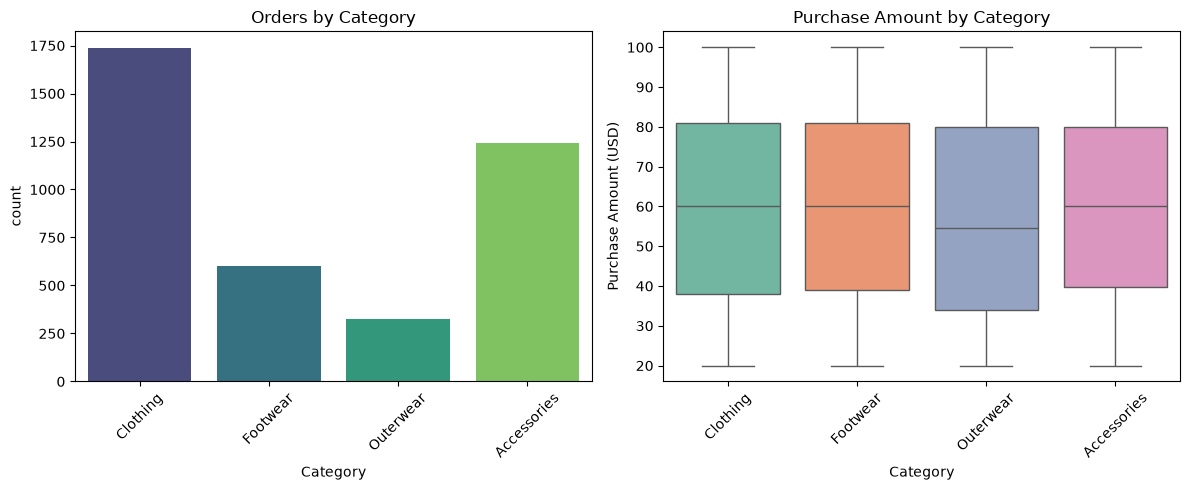

In [13]:
# Bonus: Quick Visual Check (Optional)
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.countplot(data=df_clean, x='Category', palette='viridis')
plt.title('Orders by Category')
plt.xticks(rotation=45)

plt.subplot(1,2,2)
sns.boxplot(data=df_clean, x='Category', y='Purchase Amount (USD)', palette='Set2')
plt.title('Purchase Amount by Category')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()